In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
FILE_PRECLINICAL_LINKING = "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/04_normalization/data/mapped_all/entities_drug_disease_preclin.csv" #_neuro.csv"

# from scratch/Clinical_Pipeline/10_Filter_Neuro.ipynb
FILE_CLINICAL_LINKING = "/scratch/sdonev/Clinical_Pipeline/data/linked_to_ontologies/entities_drug_disease_clin.csv" #"_neuro.csv"
FILE_CLINICAL_METADATA = "/scratch/sdonev/Clinical_Pipeline/data/raw_aact/mv_interventional_drug_studies_20260302.csv" #_neuro.csv"
PRECLINICAL_METADATA_PATH = "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/02_animal_study_classification/data/animal_studies/full_pubmed_filtered_animal_6002827_metadata.csv" #"/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/03_IE_ner/data/animal_studies_with_drug_disease/animal_studies_metadata_595768.csv"

OUTPUT_DIR = "06_preclin_clinic_join/data/joined_data/"

conditions_col_to_use = "merged_mondo_label"
drugs_col_to_use =  "merged_umls_label" 

conditions_col_to_use_clinical =  "merged_mondo_label"
drugs_col_to_use_clinical =  "merged_umls_label"


In [3]:
def count_unique_from_pipe_column(df, column):
    """
    Count unique items and their frequencies in a DataFrame column containing '|' separated values.

    Returns:
        total_unique (int): total number of unique non-empty terms
        freq_df (pd.DataFrame): columns ['term', 'n_articles']
                               where 'n_articles' = number of unique PMIDs (rows) mentioning that term
    """
    import pandas as pd

    # explode values
    all_items = (
        df[[column, "PMID"]]
        .dropna(subset=[column])
        .assign(**{column: df[column].astype(str).str.split("|")})
        .explode(column)
    )
    all_items[column] = all_items[column].str.strip()
    all_items = all_items[all_items[column] != ""]

    # count how many distinct PMIDs mention each term
    freq = (
        all_items.groupby(column)["PMID"]
        .nunique()
        .reset_index(name="n_articles")
        .sort_values("n_articles", ascending=False)
    )

    total_unique = freq.shape[0]
    return total_unique, freq


## Preclinical Data

In [4]:
# --- Load Preclinical Data ---
preclinical_df = pd.read_csv(FILE_PRECLINICAL_LINKING)
print(f"Shape of preclinical_df: {preclinical_df.shape}, {preclinical_df.PMID.nunique()} unique PMIDs")
metadata_df_year = pd.read_csv(PRECLINICAL_METADATA_PATH)[['PMID','year']]
metadata_df_year = metadata_df_year.drop_duplicates(subset=['PMID'])

preclinical_df = preclinical_df.merge(metadata_df_year, on="PMID", how="left")
preclinical_df = preclinical_df.rename(columns={
    'year': 'pub_year'
})

Shape of preclinical_df: (540999, 14), 540999 unique PMIDs


In [5]:
preclinical_df.head()

,PMID,unique_conditions_linkbert_predictions,disease_mondo_term_norm,disease_mondo_termid,disease_term_mondo_clean,nearest_dataset_parent_label,merged_mondo_label,merged_mondo_termid,unique_interventions_linkbert_predictions,drug_umls_term_norm,drug_umls_termid,nearest_dataset_parent_umls_label,merged_umls_label,merged_umls_termid,pub_year
0,31733831,asthma,asthma,MONDO:0004979,asthma,-1,asthma,MONDO:0004979,isorhynchophylline,isorhynchophylline,C0245133,-1,isorhynchophylline,C0245133,2020.0
1,31733833,myocardial infarction,myocardial infarction,MONDO:0005068,myocardial infarction,-1,myocardial infarction,MONDO:0005068,mir-1192|antgomir-1192|agomir-1192,"MIRN1192 microRNA, mouse|antgomir-1192|agomir-...",C3849422|-1|-1,-1,"MIRN1192 microRNA, mouse|antgomir-1192|agomir-...",C3849422|-1|-1,2020.0
2,31733925,systemic lupus erythematosus,systemic lupus erythematosus,MONDO:0007915,systemic lupus erythematosus,-1,systemic lupus erythematosus,MONDO:0007915,hla-g2|g2,HLA-G2 Isoform|g2,C0967254|-1,-1,HLA-G2 Isoform|g2,C0967254|-1,2020.0
3,31733940,cognitive impairment,cognitive disorder,MONDO:0002039,cognitive disorder,-1,cognitive disorder,MONDO:0002039,minocycline,Minocycline,C0026187,-1,Minocycline,C0026187,2020.0
4,31734027,cumulative peripheral neuropathy|oxaliplatin-i...,cumulative peripheral neuropathy|oxaliplatin-i...,-1|-1|MONDO:0003620,cumulative peripheral neuropathy|oxaliplatin-i...,-1,cumulative peripheral neuropathy|oxaliplatin-i...,-1|-1|MONDO:0003620,tadalafil|phosphodiesterase type 5 inhibitor t...,Tadalafil|Tadalafil,C1176316|C1176316,-1,Tadalafil,C1176316,2019.0


In [6]:
n_unique, freq = count_unique_from_pipe_column(preclinical_df, "merged_umls_label")
print(f"Unique count: {n_unique}")

Unique count: 292681


In [7]:
freq

,merged_umls_label,n_articles
35554,Dexamethasone,5806
29729,Acetylcysteine,4559
46270,NG-Nitroarginine Methyl Ester,4306
53058,Sirolimus,4107
35966,Doxorubicin,4021
...,...,...
118861,db7,1
118862,db745b,1
118863,db76,1
118864,db766 azo,1


In [8]:
# Split and explode conditions and drugs
#preclinical_df[conditions_col_to_use] = preclinical_df[conditions_col_to_use].str.split("|")
#preclinical_df = preclinical_df.explode(conditions_col_to_use, ignore_index=True)

# DISEASE
cols_to_explode = [
    conditions_col_to_use,
    "merged_mondo_termid"
    
]

for col in cols_to_explode:
    preclinical_df[col] = preclinical_df[col].astype(str).str.split("|")

preclinical_df = preclinical_df.explode(cols_to_explode, ignore_index=True)
print(f"Unique disease before length filter: {preclinical_df[conditions_col_to_use].nunique()}")
preclinical_df = preclinical_df[preclinical_df[conditions_col_to_use].fillna("").str.len() > 2]
print(f"Unique disease: {preclinical_df[conditions_col_to_use].nunique()}")

# DRUG
cols_to_explode = [
    drugs_col_to_use,     # e.g. drug names
    "merged_umls_termid",             # IDs
    
]

for col in cols_to_explode:
    preclinical_df[col] = preclinical_df[col].astype(str).str.split("|")

preclinical_df = preclinical_df.explode(cols_to_explode, ignore_index=True)
print(f"Unique drugs before length filter: {preclinical_df[drugs_col_to_use].nunique()}")

preclinical_df = preclinical_df[preclinical_df[drugs_col_to_use].fillna("").str.len() > 2]
print(f"Unique drugs: {preclinical_df[drugs_col_to_use].nunique()}")

preclinical_df = preclinical_df.drop_duplicates()

# Strip whitespace and convert to lowercase
preclinical_df[conditions_col_to_use] = preclinical_df[conditions_col_to_use].str.strip().str.lower()
preclinical_df[drugs_col_to_use] = preclinical_df[drugs_col_to_use].str.strip().str.lower()

Unique disease before length filter: 80055
Unique disease: 79820
Unique drugs before length filter: 292588
Unique drugs: 291540


In [9]:
preclinical_df['disease<>drug'] = (
    preclinical_df[conditions_col_to_use] + " <> " + preclinical_df[drugs_col_to_use]
)

In [10]:
preclinical_df.head()

,PMID,unique_conditions_linkbert_predictions,disease_mondo_term_norm,disease_mondo_termid,disease_term_mondo_clean,nearest_dataset_parent_label,merged_mondo_label,merged_mondo_termid,unique_interventions_linkbert_predictions,drug_umls_term_norm,drug_umls_termid,nearest_dataset_parent_umls_label,merged_umls_label,merged_umls_termid,pub_year,disease<>drug
0,31733831,asthma,asthma,MONDO:0004979,asthma,-1,asthma,MONDO:0004979,isorhynchophylline,isorhynchophylline,C0245133,-1,isorhynchophylline,C0245133,2020.0,asthma <> isorhynchophylline
1,31733833,myocardial infarction,myocardial infarction,MONDO:0005068,myocardial infarction,-1,myocardial infarction,MONDO:0005068,mir-1192|antgomir-1192|agomir-1192,"MIRN1192 microRNA, mouse|antgomir-1192|agomir-...",C3849422|-1|-1,-1,"mirn1192 microrna, mouse",C3849422,2020.0,"myocardial infarction <> mirn1192 microrna, mouse"
2,31733833,myocardial infarction,myocardial infarction,MONDO:0005068,myocardial infarction,-1,myocardial infarction,MONDO:0005068,mir-1192|antgomir-1192|agomir-1192,"MIRN1192 microRNA, mouse|antgomir-1192|agomir-...",C3849422|-1|-1,-1,antgomir-1192,-1,2020.0,myocardial infarction <> antgomir-1192
3,31733833,myocardial infarction,myocardial infarction,MONDO:0005068,myocardial infarction,-1,myocardial infarction,MONDO:0005068,mir-1192|antgomir-1192|agomir-1192,"MIRN1192 microRNA, mouse|antgomir-1192|agomir-...",C3849422|-1|-1,-1,agomir-1192,-1,2020.0,myocardial infarction <> agomir-1192
4,31733925,systemic lupus erythematosus,systemic lupus erythematosus,MONDO:0007915,systemic lupus erythematosus,-1,systemic lupus erythematosus,MONDO:0007915,hla-g2|g2,HLA-G2 Isoform|g2,C0967254|-1,-1,hla-g2 isoform,C0967254,2020.0,systemic lupus erythematosus <> hla-g2 isoform


In [11]:
mapping_lookup_preclin_drug = dict(
    zip(
        preclinical_df["merged_umls_label"],
        preclinical_df["merged_umls_termid"]
    )
)

mapping_lookup_preclin_disease = dict(
    zip(
        preclinical_df["merged_mondo_label"],
        preclinical_df["merged_mondo_termid"]
    )
)

## Clinical Data

In [12]:
# --- Load Clinical Data ---
clinical_df = pd.read_csv(FILE_CLINICAL_LINKING)
print(f"Shape of clinical_df: {clinical_df.shape}, {clinical_df.nct_id.nunique()} unique NCTIDs")

# DISEASE
cols_to_explode = [
    conditions_col_to_use_clinical,
    "merged_mondo_termid"
    
]

for col in cols_to_explode:
    clinical_df[col] = clinical_df[col].astype(str).str.split("|")

clinical_df = clinical_df.explode(cols_to_explode, ignore_index=True)
print(f"Unique disease before length filter: {clinical_df[conditions_col_to_use_clinical].nunique()}")
clinical_df = clinical_df[clinical_df[conditions_col_to_use_clinical].fillna("").str.len() > 2]
print(f"Unique disease: {clinical_df[conditions_col_to_use_clinical].nunique()}")

# DRUG
cols_to_explode = [
    drugs_col_to_use_clinical,     # e.g. drug names
    "merged_umls_termid",             # IDs
]

for col in cols_to_explode:
    clinical_df[col] = clinical_df[col].astype(str).str.split("|")

clinical_df = clinical_df.explode(cols_to_explode, ignore_index=True)
print(f"Unique drugs before length filter: {clinical_df[drugs_col_to_use_clinical].nunique()}")
clinical_df = clinical_df[clinical_df[drugs_col_to_use_clinical].fillna("").str.len() > 2]
print(f"Unique drugs: {clinical_df[drugs_col_to_use_clinical].nunique()}")

# Strip whitespace and convert to lowercase
clinical_df[conditions_col_to_use_clinical] = clinical_df[conditions_col_to_use_clinical].str.strip().str.lower()
clinical_df[drugs_col_to_use_clinical] = clinical_df[drugs_col_to_use_clinical].str.strip().str.lower()


Shape of clinical_df: (217488, 18), 217488 unique NCTIDs
Unique disease before length filter: 148951
Unique disease: 148686
Unique drugs before length filter: 90539
Unique drugs: 90073


In [13]:
# Create disease-drug key
clinical_df['disease<>drug'] = (
    clinical_df[conditions_col_to_use_clinical] + " <> " + clinical_df[drugs_col_to_use_clinical]
)


# Load and merge clinical metadata (phase + status)
metadata_df = pd.read_csv(FILE_CLINICAL_METADATA)[['nct_id', 'phase', 'overall_status', 'start_date', 'completion_date']]
# get start year
metadata_df['start_date'] = pd.to_datetime(metadata_df['start_date'], errors='coerce')
metadata_df['trial_start_year'] = metadata_df['start_date'].dt.year
# get completion year
metadata_df['completion_date'] = pd.to_datetime(metadata_df['completion_date'], errors='coerce')
metadata_df['trial_completion_year'] = metadata_df['completion_date'].dt.year
metadata_df = metadata_df.drop_duplicates()



In [14]:
clinical_df = clinical_df.merge(metadata_df, on='nct_id', how='left')

In [15]:
clinical_df.shape

(2237465, 25)

In [16]:
clinical_df.head()

,nct_id,merged_condition_names,disease_mondo_termid,disease_mondo_term_norm,disease_term_mondo_clean,disease_termid_mondo_clean,nearest_dataset_parent_mondo,nearest_dataset_parent_label,merged_mondo_termid,merged_mondo_label,...,nearest_dataset_parent_umls_label,merged_umls_termid,merged_umls_label,disease<>drug,phase,overall_status,start_date,completion_date,trial_start_year,trial_completion_year
0,NCT00000114,Retinitis Pigmentosa,MONDO:0008377,retinitis pigmentosa 1,retinitis pigmentosa,MONDO:0008377,-1,-1,MONDO:0008377,retinitis pigmentosa,...,-1,C0042839,vitamin a,retinitis pigmentosa <> vitamin a,PHASE3,COMPLETED,1984-05-31,1987-06-30,1984.0,1987.0
1,NCT00000114,Retinitis Pigmentosa,MONDO:0008377,retinitis pigmentosa 1,retinitis pigmentosa,MONDO:0008377,-1,-1,MONDO:0008377,retinitis pigmentosa,...,-1,C0042874,vitamin e,retinitis pigmentosa <> vitamin e,PHASE3,COMPLETED,1984-05-31,1987-06-30,1984.0,1987.0
2,NCT00000102,Congenital Adrenal Hyperplasia,MONDO:0015898,adrenogenital syndrome,adrenogenital syndrome,MONDO:0015898,-1,-1,MONDO:0015898,adrenogenital syndrome,...,Nifedipine,C0017710,glucocorticoids,adrenogenital syndrome <> glucocorticoids,PHASE1/PHASE2,COMPLETED,NaT,NaT,NaN,NaN
3,NCT00000102,Congenital Adrenal Hyperplasia,MONDO:0015898,adrenogenital syndrome,adrenogenital syndrome,MONDO:0015898,-1,-1,MONDO:0015898,adrenogenital syndrome,...,Nifedipine,C0028066,nifedipine,adrenogenital syndrome <> nifedipine,PHASE1/PHASE2,COMPLETED,NaT,NaT,NaN,NaN
4,NCT00000102,Congenital Adrenal Hyperplasia,MONDO:0015898,adrenogenital syndrome,adrenogenital syndrome,MONDO:0015898,-1,-1,MONDO:0015898,adrenogenital syndrome,...,Nifedipine,C0700861,procardia,adrenogenital syndrome <> procardia,PHASE1/PHASE2,COMPLETED,NaT,NaT,NaN,NaN


## Aggregate for merging

In [17]:
clinical_doc_id_col = "nct_id"
clinical_key_col = 'disease<>drug'

In [18]:
clinical_unique = (
        clinical_df
        .sort_values(clinical_doc_id_col)  # optional: enforce a deterministic order
        .drop_duplicates(subset=[clinical_key_col, clinical_doc_id_col], keep='first')
    )
# === Aggregate clinical data by key ===
clinical_agg = (
        clinical_unique
        .groupby(clinical_key_col)
        .agg({
            clinical_doc_id_col: list,
            'merged_mondo_termid': 'first',
            'merged_umls_termid': 'first',
            'merged_mondo_label': 'first',
            'merged_umls_label': 'first',
            'trial_start_year':     list,
            'trial_completion_year':     list,
            'phase':              list,
            'overall_status':     list
        })
        .reset_index()
        )
    

# Rename columns for clarity and consistency
clinical_agg.rename(columns={
    clinical_key_col: 'normalized_key',
    clinical_doc_id_col: 'clinical_doc_ids'
}, inplace=True)

# Add count of clinical documents per key
clinical_agg['clinical_count'] = clinical_agg['clinical_doc_ids'].apply(len)

In [19]:
clinical_agg[clinical_agg['merged_mondo_termid']!="-1"]

,normalized_key,clinical_doc_ids,merged_mondo_termid,merged_umls_termid,merged_mondo_label,merged_umls_label,trial_start_year,trial_completion_year,phase,overall_status,clinical_count
3742,11q22.2q22.3 microdeletion syndrome <> arabino...,[NCT01253460],MONDO:0018632,C0003680,11q22.2q22.3 microdeletion syndrome,arabinonucleosides,[2011.0],[2019.0],[PHASE2],[TERMINATED],1
3743,11q22.2q22.3 microdeletion syndrome <> cycloph...,[NCT01253460],MONDO:0018632,C0010583,11q22.2q22.3 microdeletion syndrome,cyclophosphamide,[2011.0],[2019.0],[PHASE2],[TERMINATED],1
3744,11q22.2q22.3 microdeletion syndrome <> rituximab,[NCT01253460],MONDO:0018632,C0393022,11q22.2q22.3 microdeletion syndrome,rituximab,[2011.0],[2019.0],[PHASE2],[TERMINATED],1
3745,11q22.2q22.3 microdeletion syndrome <> sapacit...,[NCT01253460],MONDO:0018632,C0764827,11q22.2q22.3 microdeletion syndrome,sapacitabine,[2011.0],[2019.0],[PHASE2],[TERMINATED],1
3746,11q22.2q22.3 microdeletion syndrome <> sapacit...,[NCT01253460],MONDO:0018632,-1,11q22.2q22.3 microdeletion syndrome,"sapacitabine, cyclophosphamide, and rituximab",[2011.0],[2019.0],[PHASE2],[TERMINATED],1
...,...,...,...,...,...,...,...,...,...,...,...
1305265,zygomycosis <> amphotericin b,"[NCT00467883, NCT05468372]",MONDO:0019136,C0002679,zygomycosis,amphotericin b,"[2007.0, 2022.0]","[2013.0, 2025.0]","[PHASE2, PHASE2]","[COMPLETED, RECRUITING]",2
1305266,zygomycosis <> deferasirox,[NCT00419770],MONDO:0019136,C1619629,zygomycosis,deferasirox,[2007.0],[2010.0],[PHASE2],[COMPLETED],1
1305267,zygomycosis <> isavuconazole,[NCT06440915],MONDO:0019136,C1832021,zygomycosis,isavuconazole,[2024.0],[2026.0],[nan],[RECRUITING],1
1305268,zygomycosis <> liposomal amphotericin b,[NCT00467883],MONDO:0019136,C1145701,zygomycosis,liposomal amphotericin b,[2007.0],[2013.0],[PHASE2],[COMPLETED],1


In [20]:
clinical_pairs = set(clinical_agg['normalized_key'])

In [21]:
preclinical_key_col = 'disease<>drug'
preclinical_doc_id_col = "PMID"
preclinical_disease_col = conditions_col_to_use

In [22]:
# === Aggregate preclinical data by key ===
preclinical_agg = preclinical_df.groupby(preclinical_key_col).agg({
    preclinical_doc_id_col: list,
    'pub_year':list,
    'merged_mondo_termid': 'first',
    'merged_umls_termid': 'first',
}).reset_index()

# Rename columns for consistency
preclinical_agg.rename(columns={
    preclinical_key_col: 'normalized_key',
    preclinical_doc_id_col: 'preclinical_doc_ids',
}, inplace=True)

# Add count of preclinical documents per key
preclinical_agg['preclinical_count'] = preclinical_agg['preclinical_doc_ids'].apply(len)

In [23]:
preclinical_agg.head()

,normalized_key,preclinical_doc_ids,pub_year,merged_mondo_termid,merged_umls_termid,preclinical_count
0,""" hemorrhagic shock <> saline",[1742862],[1991.0],-1,C0036082,1
1,""" indium lung <> acid, edetic",[34229798],[2021.0],-1,C0013618,1
2,""" ischemic hepatitis <> allopurinol",[9156787],[1996.0],-1,C0002144,1
3,""" nitrozation stress <> s-(4-quinazolyl) merca...",[15341075],[2004.0],-1,-1,1
4,""" stunning <> alpha tocopherol analogue",[8143306],[1994.0],-1,-1,1


In [24]:
preclinical_pairs = set(preclinical_agg['normalized_key'])

## Merge clinical and preclinical on disease <> drug

In [25]:
merged_df = pd.merge(clinical_agg, preclinical_agg, on='normalized_key', how='outer', suffixes=("", "_right"))

In [26]:
def clean_and_sort_study_data(df):
    """
    Cleans and sorts a merged clinical/preclinical DataFrame by removing invalid rows
    and ordering by study counts.

    Specifically:
    - Sorts the DataFrame in descending order of 'clinical_count' and 'preclinical_count'.
    - Removes rows where either 'clinical_count' or 'preclinical_count' is NaN.
    - Removes rows where the 'drug' name is missing or has 3 or fewer characters.
    - Prints the shape before and after filtering for transparency.

    Parameters:
    ----------
    df : pd.DataFrame
        A DataFrame containing 'clinical_count', 'preclinical_count', and 'drug'.

    Returns:
    -------
    pd.DataFrame
        The cleaned and sorted DataFrame.
    """
    print(f'Input shape of merged for cleaning: {df.shape}')

    # Sort by descending clinical and preclinical study counts
    sorted_df = df.sort_values(
        by=['clinical_count', 'preclinical_count'],
        ascending=[False, False]
    )

    # Remove rows with missing study counts
    filtered_df = sorted_df.dropna(subset=['clinical_count', 'preclinical_count'])
    print(f'Shape after filtering NaN counts: {filtered_df.shape}')

    # Remove rows with invalid or too-short drug names
    #filtered_df = filtered_df[
    #    filtered_df['drug'].apply(lambda x: isinstance(x, str) and len(x.strip()) > 3)
    #]
    #print(f'Shape after filtering short or invalid drugs: {filtered_df.shape}')

    print(f'Shape after filtering empty counts and short drugs: {filtered_df.shape}')
    return filtered_df

In [27]:
merged_df.head()

,normalized_key,clinical_doc_ids,merged_mondo_termid,merged_umls_termid,merged_mondo_label,merged_umls_label,trial_start_year,trial_completion_year,phase,overall_status,clinical_count,preclinical_doc_ids,pub_year,merged_mondo_termid_right,merged_umls_termid_right,preclinical_count
0,""" acquired resistance "" to egfr tyrosine kinas...",[NCT01259089],-1,C2348996,""" acquired resistance "" to egfr tyrosine kinas...",auy922,[2011.0],[2014.0],[PHASE1/PHASE2],[COMPLETED],1.0,NaN,NaN,NaN,NaN,NaN
1,""" acquired resistance "" to egfr tyrosine kinas...",[NCT01259089],-1,C1135135,""" acquired resistance "" to egfr tyrosine kinas...",erlotinib,[2011.0],[2014.0],[PHASE1/PHASE2],[COMPLETED],1.0,NaN,NaN,NaN,NaN,NaN
2,""" acquired resistance "" to egfr tyrosine kinas...",[NCT01259089],-1,-1,""" acquired resistance "" to egfr tyrosine kinas...",hsp 90 inhibitor,[2011.0],[2014.0],[PHASE1/PHASE2],[COMPLETED],1.0,NaN,NaN,NaN,NaN,NaN
3,""" acquired resistance "" to egfr tyrosine kinas...",[NCT01259089],-1,-1,""" acquired resistance "" to egfr tyrosine kinas...",hsp90 inhibitor,[2011.0],[2014.0],[PHASE1/PHASE2],[COMPLETED],1.0,NaN,NaN,NaN,NaN,NaN
4,""" acquired resistance "" to egfr tyrosine kinas...",[NCT01259089],-1,C1533491,""" acquired resistance "" to egfr tyrosine kinas...","hydrochloride, erlotinib",[2011.0],[2014.0],[PHASE1/PHASE2],[COMPLETED],1.0,NaN,NaN,NaN,NaN,NaN


In [28]:
filtered_df = clean_and_sort_study_data(merged_df)
filtered_df.head()

Input shape of merged for cleaning: (3035222, 16)
Shape after filtering NaN counts: (78107, 16)
Shape after filtering empty counts and short drugs: (78107, 16)


,normalized_key,clinical_doc_ids,merged_mondo_termid,merged_umls_termid,merged_mondo_label,merged_umls_label,trial_start_year,trial_completion_year,phase,overall_status,clinical_count,preclinical_doc_ids,pub_year,merged_mondo_termid_right,merged_umls_termid_right,preclinical_count
323830,diabetes mellitus <> metformin,"[NCT00004992, NCT00015626, NCT00032487, NCT000...",MONDO:0005015,C0025598,diabetes mellitus,metformin,"[1996.0, nan, 2000.0, 2001.0, 2002.0, 2002.0, ...","[2001.0, nan, 2008.0, 2003.0, 2003.0, 2003.0, ...","[PHASE3, PHASE2, PHASE3, PHASE3, PHASE4, PHASE...","[COMPLETED, COMPLETED, COMPLETED, COMPLETED, C...",1402.0,"[31918925, 31188777, 27059001, 33862494, 35784...","[2020.0, 2019.0, 2016.0, 2021.0, 2022.0, 2024....",MONDO:0005015,C0025598,656.0
777083,neoplasm <> monoclonal antibody,"[NCT00002458, NCT00002482, NCT00002560, NCT000...",MONDO:0005070,C0003250,neoplasm,monoclonal antibody,"[1987.0, 1991.0, 1994.0, 1995.0, 1997.0, 1997....","[2001.0, nan, 2005.0, 2017.0, 2002.0, 2006.0, ...","[PHASE2, PHASE1/PHASE2, PHASE2, PHASE2, PHASE1...","[COMPLETED, UNKNOWN, COMPLETED, WITHDRAWN, COM...",1156.0,"[15958639, 14726917, 16961139, 28502153, 96220...","[2005.0, 2004.0, 2006.0, 2016.0, 1998.0, 2021....",MONDO:0005070,C0003250,17.0
774336,neoplasm <> cisplatin,"[NCT00001569, NCT00002472, NCT00002477, NCT000...",MONDO:0005070,C0008838,neoplasm,cisplatin,"[1997.0, 1991.0, 1991.0, 1991.0, 1992.0, 1993....","[2002.0, 2005.0, nan, 2000.0, 2013.0, 2000.0, ...","[PHASE1, PHASE2, PHASE3, PHASE2, PHASE3, PHASE...","[COMPLETED, COMPLETED, UNKNOWN, COMPLETED, COM...",914.0,"[28472102, 26578208, 39471751, 7791337, 395554...","[2017.0, 2016.0, 2024.0, 1995.0, 1986.0, 1991....",MONDO:0005070,C0008838,102.0
187089,cancer <> monoclonal antibody,"[NCT00002589, NCT00002890, NCT00003150, NCT000...",MONDO:0004992,C0003250,cancer,monoclonal antibody,"[1994.0, 1996.0, 1997.0, 1998.0, 1998.0, 1997....","[nan, 2001.0, 2006.0, nan, 2002.0, 2002.0, 200...","[PHASE2, PHASE1, PHASE3, PHASE3, PHASE3, PHASE...","[UNKNOWN, COMPLETED, COMPLETED, COMPLETED, COM...",853.0,"[38201482, 18046482, 26405573, 23771513, 35262...","[2023.0, 2007.0, 2015.0, 2013.0, 2022.0, 2020....",MONDO:0004992,C0003250,14.0
490036,her2 positive breast carcinoma <> trastuzumab,"[NCT00003440, NCT00003612, NCT00003797, NCT000...",MONDO:0006244,C0728747,her2 positive breast carcinoma,trastuzumab,"[1998.0, 1999.0, 1999.0, 1999.0, 1999.0, 1999....","[nan, 2019.0, nan, 2004.0, 2009.0, nan, 2019.0...","[PHASE3, PHASE2, PHASE2, PHASE2, PHASE2, PHASE...","[COMPLETED, COMPLETED, UNKNOWN, COMPLETED, COM...",791.0,"[33389387, 31160077, 26712117, 38751436, 33479...","[2021.0, 2019.0, 2016.0, 2024.0, 2021.0, 2020....",MONDO:0006244,C0728747,111.0


In [29]:
phase_order = {
    'PHASE_UNKNOWN': -1,
    'NOT_APPLICABLE': -1,   # optional if it exists

    'EARLY_PHASE1': 0,
    'PHASE1': 1,
    'PHASE1/PHASE2': 1.5,
    'PHASE2': 2,
    'PHASE2/PHASE3': 2.5,
    'PHASE3': 3,
    'PHASE4': 4,
}

# Get max phase for each row
def get_max_phase(phases):
    max_val = -1
    max_phase = 'PHASE_UNKNOWN'
    
    for phase in phases:
        val = phase_order.get(phase, -1)
        if val > max_val:
            max_val = val
            max_phase = phase
            
    return max_phase

def has_phase3(p):  # includes PHASE2/PHASE3 etc.
    p = str(p).strip()
    return p == "PHASE3" or "PHASE3" in p.split("/")

def has_phase4(p):
    p = str(p).strip()
    return p == "PHASE4" or "PHASE4" in p.split("/")
    
def first_completed_phase3_completion_year(phases, statuses, completion_years):
    """
    Return the earliest completion year among trials that are Phase 3 and Completed.
    Returns None if not available / no matches.
    """
    if not all(isinstance(x, list) for x in [phases, statuses, completion_years]):
        return None

    years = []
    for p, s, y in zip(phases, statuses, completion_years):
        if (has_phase3(p)) and (str(s).strip().lower() == "COMPLETED"):
            try:
                yy = int(y) if y is not None and str(y).strip() != "" else None
            except Exception:
                yy = None
            if yy is not None:
                years.append(yy)

    return min(years) if years else None
    
def as_list(x):
    # your column already looks like lists, but this makes it safe
    if isinstance(x, list):
        return [str(v).strip() for v in x]
    if pd.isna(x):
        return []
    return [v.strip() for v in str(x).split("|") if v.strip()]

In [30]:
filtered_df['max_phase'] = filtered_df['phase'].apply(get_max_phase)

filtered_df["at_least_one_phase3"] = filtered_df["phase"].apply(lambda x: any(has_phase3(p) for p in as_list(x)))
filtered_df["at_least_one_phase4"] = filtered_df["phase"].apply(lambda x: any(has_phase4(p) for p in as_list(x)))

filtered_df["at_least_one_phase3_completed"] = filtered_df.apply(
    lambda row: any(
        has_phase3(p) and str(s).strip().upper() == "COMPLETED"
        for p, s in zip(as_list(row["phase"]), as_list(row["overall_status"]))
    ),
    axis=1,
)


filtered_df['min_trial_start_year'] = filtered_df['trial_start_year'].apply(
    lambda x: min(x) if isinstance(x, list) and len(x) > 0 else None
)

filtered_df['max_trial_start_year'] = filtered_df['trial_start_year'].apply(
    lambda x: max(x) if isinstance(x, list) and len(x) > 0 else None
)

filtered_df["min_phase_4_year"] = filtered_df.apply(
    lambda row: min(
        [year for phase, year in zip(row["phase"], row["trial_start_year"]) if has_phase4(phase)], 
        default=None
    ),
    axis=1
)

filtered_df["trial_completion_year_first_completed_phase3"] = filtered_df.apply(
    lambda row: first_completed_phase3_completion_year(
        row["phase"],
        row["overall_status"],
        row["trial_completion_year"],
    ),
    axis=1
)

In [31]:
filtered_df = filtered_df.drop(columns=['merged_umls_termid_right', 'merged_mondo_termid_right'])

## Add FDA info

In [32]:
fda_drug_disease = pd.read_csv("/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/10_use_case_disease_focus/out/FDA_drug_disease_pairs_mapped_both.csv")


In [33]:
fda_drug_disease['disease<>drug'] = (
    fda_drug_disease["disease_mondo_term_norm"] + " <> " + fda_drug_disease["merged_umls_label"]
)
fda_drug_disease = fda_drug_disease.add_prefix("fda_")
fda_drug_disease['fda_AP']=True
fda_drug_disease.head()

,fda_merged_umls_label,fda_disease_mondo_term_norm,fda_earliest_year,fda_disease,fda_documents,fda_disease<>drug,fda_AP
0,(+)-Tolterodine,frequency,1998.0,frequency,"['ANDA077006', 'ANDA079141', 'ANDA203016', 'AN...",frequency <> (+)-Tolterodine,True
1,(+)-Tolterodine,overactive bladder,1998.0,overactive bladder,"['ANDA077006', 'ANDA079141', 'ANDA203016', 'AN...",overactive bladder <> (+)-Tolterodine,True
2,(+)-Tolterodine,urge urinary incontinence,1998.0,urge urinary incontinence,"['ANDA077006', 'ANDA079141', 'ANDA203016', 'AN...",urge urinary incontinence <> (+)-Tolterodine,True
3,(+)-Tolterodine,urgency,1998.0,urgency,"['ANDA077006', 'ANDA079141', 'ANDA203016', 'AN...",urgency <> (+)-Tolterodine,True
4,(+-)-Milnacipran,fibromyalgia,2009.0,fibromyalgia,"['ANDA205081', 'NDA022256']",fibromyalgia <> (+-)-Milnacipran,True


In [34]:
fda_pairs = set(fda_drug_disease['fda_disease<>drug'])

In [35]:
len(fda_pairs)

9350

In [36]:
# pairwise overlaps
fda_drugs = {str(x).strip().lower() for x in fda_pairs if x}
clinical_drugs = {str(x).strip().lower() for x in clinical_pairs if x}
preclinical_drugs = {str(x).strip().lower() for x in preclinical_pairs if x}

fda_clinical = fda_drugs & clinical_drugs
fda_preclinical = fda_drugs & preclinical_drugs
clinical_preclinical = clinical_drugs & preclinical_drugs

# all three
all_three = fda_drugs & clinical_drugs & preclinical_drugs

print("FDA ∩ Clinical:", len(fda_clinical))
print("FDA ∩ Preclinical:", len(fda_preclinical))
print("Clinical ∩ Preclinical:", len(clinical_preclinical))
print("All three:", len(all_three))


FDA ∩ Clinical: 4249
FDA ∩ Preclinical: 3065
Clinical ∩ Preclinical: 78107
All three: 2534


In [37]:
fda_preclin_not_clin = (fda_drugs & preclinical_drugs) - clinical_drugs
len(fda_preclin_not_clin)

531

In [38]:
fda_drug_disease["fda_disease<>drug"] = (
    fda_drug_disease["fda_disease<>drug"].astype(str).str.strip().str.lower()
)
filtered_df["normalized_key"] = (
    filtered_df["normalized_key"].astype(str).str.strip().str.lower()
)
filtered_df = filtered_df.merge(
    fda_drug_disease,
    how="left",
    left_on="normalized_key",
    right_on="fda_disease<>drug"
)
filtered_df["fda_AP"] = filtered_df["fda_AP"].fillna(False).astype(bool)


In [39]:
filtered_df["fda_AP"].value_counts()


fda_AP
False    75573
True      2534
Name: count, dtype: int64

#### FDA only

In [40]:
targets = fda_preclin_not_clin

filtered_fda_only_preclin = preclinical_agg[
    preclinical_agg['normalized_key'].isin(targets)
]
filtered_fda_only_preclin = filtered_fda_only_preclin.merge(
    fda_drug_disease,
    how="left",
    left_on="normalized_key",
    right_on="fda_disease<>drug"
)
filtered_fda_only_preclin["fda_AP"] = filtered_fda_only_preclin["fda_AP"].fillna(False).astype(bool)


In [41]:
filtered_fda_only_preclin.to_csv("/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/10_use_case_disease_focus/out/translation_table_drug_disease_neuro_FDA_only.csv", index=False) # used in Translation_05!
filtered_fda_only_preclin.to_csv("./out/translation_table_drug_disease_neuro_FDA_only.csv", index=False) 

In [42]:
preclinical_agg[preclinical_agg['normalized_key']=="allergic rhinitis <> cromolyn sodium"]

,normalized_key,preclinical_doc_ids,pub_year,merged_mondo_termid,merged_umls_termid,preclinical_count
93933,allergic rhinitis <> cromolyn sodium,"[18627797, 22852116, 3220322, 15187427]","[2008.0, 2011.0, 1988.0, 2004.0]",MONDO:0011786,C0012694,4


#### save for association analysis

In [43]:
filtered_df.to_csv("/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/10_use_case_disease_focus/out/translation_table_drug_disease_all.csv", index=False) # used in Translation_05!
filtered_df.to_csv("./out/translation_table_drug_disease_all.csv", index=False) # used in Translation_05!

In [44]:
filtered_df[filtered_df["fda_earliest_year"].isna() & filtered_df['at_least_one_phase4']][['normalized_key', 'clinical_doc_ids', 'merged_mondo_termid',
       'merged_umls_termid', 'merged_mondo_label', 'merged_umls_label',
       'trial_start_year', 'phase', 'overall_status', 'clinical_count',
       'preclinical_doc_ids', 'pub_year', 'preclinical_count','min_phase_4_year', 'trial_completion_year_first_completed_phase3']].head(5)

,normalized_key,clinical_doc_ids,merged_mondo_termid,merged_umls_termid,merged_mondo_label,merged_umls_label,trial_start_year,phase,overall_status,clinical_count,preclinical_doc_ids,pub_year,preclinical_count,min_phase_4_year,trial_completion_year_first_completed_phase3
0,diabetes mellitus <> metformin,"[NCT00004992, NCT00015626, NCT00032487, NCT000...",MONDO:0005015,C0025598,diabetes mellitus,metformin,"[1996.0, nan, 2000.0, 2001.0, 2002.0, 2002.0, ...","[PHASE3, PHASE2, PHASE3, PHASE3, PHASE4, PHASE...","[COMPLETED, COMPLETED, COMPLETED, COMPLETED, C...",1402.0,"[31918925, 31188777, 27059001, 33862494, 35784...","[2020.0, 2019.0, 2016.0, 2021.0, 2022.0, 2024....",656.0,2000.0,None
1,neoplasm <> monoclonal antibody,"[NCT00002458, NCT00002482, NCT00002560, NCT000...",MONDO:0005070,C0003250,neoplasm,monoclonal antibody,"[1987.0, 1991.0, 1994.0, 1995.0, 1997.0, 1997....","[PHASE2, PHASE1/PHASE2, PHASE2, PHASE2, PHASE1...","[COMPLETED, UNKNOWN, COMPLETED, WITHDRAWN, COM...",1156.0,"[15958639, 14726917, 16961139, 28502153, 96220...","[2005.0, 2004.0, 2006.0, 2016.0, 1998.0, 2021....",17.0,2025.0,None
2,neoplasm <> cisplatin,"[NCT00001569, NCT00002472, NCT00002477, NCT000...",MONDO:0005070,C0008838,neoplasm,cisplatin,"[1997.0, 1991.0, 1991.0, 1991.0, 1992.0, 1993....","[PHASE1, PHASE2, PHASE3, PHASE2, PHASE3, PHASE...","[COMPLETED, COMPLETED, UNKNOWN, COMPLETED, COM...",914.0,"[28472102, 26578208, 39471751, 7791337, 395554...","[2017.0, 2016.0, 2024.0, 1995.0, 1986.0, 1991....",102.0,2008.0,None
8,neoplasm <> paclitaxel,"[NCT00001387, NCT00001442, NCT00001507, NCT000...",MONDO:0005070,C0144576,neoplasm,paclitaxel,"[1994.0, 1995.0, 1996.0, 1997.0, nan, 1997.0, ...","[PHASE1, PHASE1, PHASE1, PHASE1, PHASE2, PHASE...","[COMPLETED, COMPLETED, COMPLETED, COMPLETED, C...",769.0,"[21726090, 10701971, 28497694, 11212270, 35890...","[2011.0, 1999.0, 2017.0, 2001.0, 2022.0, 2003....",65.0,2017.0,None
11,neoplasm <> gemcitabine,"[NCT00001449, NCT00002998, NCT00003001, NCT000...",MONDO:0005070,C0045093,neoplasm,gemcitabine,"[1995.0, 1997.0, 1997.0, 1997.0, 1997.0, 1997....","[PHASE1, PHASE2, PHASE1/PHASE2, PHASE1/PHASE2,...","[COMPLETED, COMPLETED, UNKNOWN, COMPLETED, COM...",664.0,"[24434571, 32978501, 12892825, 30227079, 24214...","[2014.0, 2020.0, 2003.0, 2018.0, 2014.0, 2008....",24.0,2013.0,None


In [45]:
filtered_df.shape

(78107, 29)

In [46]:
filtered_df.merged_mondo_label.nunique(), filtered_df.merged_umls_label.nunique()

(5079, 10100)

In [47]:
filtered_df.columns

Index(['normalized_key', 'clinical_doc_ids', 'merged_mondo_termid',
       'merged_umls_termid', 'merged_mondo_label', 'merged_umls_label',
       'trial_start_year', 'trial_completion_year', 'phase', 'overall_status',
       'clinical_count', 'preclinical_doc_ids', 'pub_year',
       'preclinical_count', 'max_phase', 'at_least_one_phase3',
       'at_least_one_phase4', 'at_least_one_phase3_completed',
       'min_trial_start_year', 'max_trial_start_year', 'min_phase_4_year',
       'trial_completion_year_first_completed_phase3', 'fda_merged_umls_label',
       'fda_disease_mondo_term_norm', 'fda_earliest_year', 'fda_disease',
       'fda_documents', 'fda_disease<>drug', 'fda_AP'],
      dtype='object')

## Report translational stats

In [48]:
from typing import Optional, List


In [49]:
def _is_linked(e, mapping_lookup):
    if e not in mapping_lookup:
        print(f"{e}: not_found")
    mid = mapping_lookup.get(e, "-1")
    #if mid == "-1":
     #   print(f"not linked entity: {e}")
    return str(mid).strip() != "-1"

def _is_linked_id_based(e_drug_id, e_disease_id):
    return (str(e_drug_id).strip() != "-1") and (str(e_disease_id).strip() != "-1")

def _is_short(e, mapping_lookup):
    if len(e.strip()) < 3:
        print(f"{e}, {_is_linked(e,mapping_lookup)}")

    return len(e.strip()) < 3

In [50]:
from typing import Any, Dict, List, Optional, Set, Tuple
import pandas as pd
import numpy as np

# Assumed to exist in your codebase
# def _is_linked_id_based(drug_id: str, disease_id: str) -> bool: ...


# ==========================================================
# 1) Filtering
# ==========================================================

def _apply_selected_disease_filters_pairbased(
    preclinical_df: pd.DataFrame,
    filtered_df: pd.DataFrame,
    fda_preclin_not_clin: Optional[List[str]],
    *,
    key_col: str,
    selected_disease: Optional[str],
) -> Tuple[pd.DataFrame, pd.DataFrame, Set[str]]:
    fda_preclin_not_clin = fda_preclin_not_clin or []

    if not selected_disease:
        return preclinical_df, filtered_df, set(fda_preclin_not_clin)

    sd_lower = selected_disease.lower()

    print(f"Filtering datasets for disease: {selected_disease}")

    preclinical_df = preclinical_df[
        preclinical_df["merged_mondo_label"].str.contains(
            selected_disease, case=False, na=False
        )
    ]

    # NOTE: keeping your original behavior: key_col contains selected_disease
    filtered_df = filtered_df[
        filtered_df[key_col].astype(str).str.contains(
            selected_disease, case=False, na=False
        )
    ]

    fda_set = {s for s in fda_preclin_not_clin if sd_lower in str(s).lower()}

    print(f"Example diseases: {preclinical_df['merged_mondo_label'].dropna().unique()[:10]}")
    print(f"Example drugs: {preclinical_df['merged_umls_label'].dropna().unique()[:10]}")
    print(f"Example FDA: {list(fda_set)[:10]}")

    return preclinical_df, filtered_df, fda_set


# ==========================================================
# 2) Calculations (ALL math here; no math in print)
# ==========================================================

def compute_clinical_reach_metrics_pairbased(
    *,
    preclinical_df: pd.DataFrame,
    filtered_df: pd.DataFrame,
    drugs_col_to_use: str,
    disease_col_to_use: str,
    fda_preclin_not_clin: Set[str],
    key_col: str = "normalized_key",
    phase4_col: str = "at_least_one_phase4",
    phase3_completed_col: str = "at_least_one_phase3_completed",
    fda_approval_col: str = "fda_AP",
) -> Tuple[
    Dict[str, Any],
    pd.DataFrame,          # linked_singletons_df
    Set[str],              # reached_clinical_entities
    np.ndarray,            # p3c_or_p4_unique
]:
    def pct(a: int, b: int) -> float:
        return (a / b * 100) if b else 0.0

    # ------------------------------------------------------
    # A) Denominators
    # ------------------------------------------------------
    clinical_unique = set(filtered_df[key_col].dropna().astype(str))

    preclin_unique_pairs = preclinical_df["disease<>drug"].dropna().astype(str).unique()
    total_unique_preclin = len(preclin_unique_pairs)

    preclin_unique_drug = len(preclinical_df["merged_umls_label"].dropna().unique())
    preclin_unique_disease = len(preclinical_df["merged_mondo_label"].dropna().unique())

    preclin_series = preclinical_df["disease<>drug"].dropna().astype(str)
    preclin_counts = preclin_series.value_counts()

    preclin_gt1 = set(preclin_counts[preclin_counts > 1].index)
    preclin_eq1 = set(preclin_counts[preclin_counts == 1].index)

    preclin_eq1_and_clin = preclin_eq1 & clinical_unique
    preclin_excl = preclin_eq1 - preclin_eq1_and_clin

    print(f"Example excluded infrequent pairs: {list(preclin_excl)[:10]}")

    preclin_gt1_rule = preclin_gt1 | preclin_eq1_and_clin
    total_unique_preclin_gt1 = len(preclin_gt1_rule)

    preclin_unique_ids = list(
        set(zip(preclinical_df[drugs_col_to_use], preclinical_df[disease_col_to_use]))
    )
    total_preclinical_linked = sum(
        _is_linked_id_based(e_drug_id, e_disease_id)
        for e_drug_id, e_disease_id in preclin_unique_ids
    )

    # singletons + linked_singletons_df
    singletons = set(preclin_counts[preclin_counts == 1].index)
    singleton_mask = preclinical_df["disease<>drug"].astype(str).isin(singletons)

    linked_mask = preclinical_df.apply(
        lambda r: _is_linked_id_based(r[drugs_col_to_use], r[disease_col_to_use]),
        axis=1,
    )
    linked_singletons_df = preclinical_df[singleton_mask & linked_mask]

    eligible_mask = preclinical_df["disease<>drug"].astype(str).isin(preclin_gt1_rule)
    preclinical_df_gt1 = preclinical_df.loc[eligible_mask]

    preclin_unique_ids_gt1 = list(
        set(zip(preclinical_df_gt1[drugs_col_to_use], preclinical_df_gt1[disease_col_to_use]))
    )
    total_preclinical_linked_gt1 = sum(
        _is_linked_id_based(e_drug_id, e_disease_id)
        for e_drug_id, e_disease_id in preclin_unique_ids_gt1
    )

    # ------------------------------------------------------
    # B) Reached clinical (pair-level)
    # ------------------------------------------------------
    reached_clinical_entities = clinical_unique | set(fda_preclin_not_clin)
    reached_clinical = len(clinical_unique) + len(fda_preclin_not_clin)

    counts_arr = np.array(filtered_df["preclinical_count"])
    total_unique_reached_clin_gt1 = int((counts_arr > 1).sum())

    clin_unique_ids = list(set(zip(filtered_df[drugs_col_to_use], filtered_df[disease_col_to_use])))
    reached_clinical_and_linked = sum(
        _is_linked_id_based(e_drug_id, e_disease_id)
        for e_drug_id, e_disease_id in clin_unique_ids
    )

    # ------------------------------------------------------
    # C) Phase 3 / Phase 4 / FDA (pair-level)
    # ------------------------------------------------------
    df_p3c_or_p4_or_fda = filtered_df[
        filtered_df[phase3_completed_col].fillna(False)
        | filtered_df[phase4_col].fillna(False)
        | filtered_df[fda_approval_col].fillna(False)
    ]

    p3c_or_p4_unique = df_p3c_or_p4_or_fda[key_col].dropna().astype(str).unique()
    reached_p3c_or_p4_or_fda = len(p3c_or_p4_unique) + len(fda_preclin_not_clin)

    p3c_or_p4_unique_ids = list(
        set(zip(df_p3c_or_p4_or_fda[drugs_col_to_use], df_p3c_or_p4_or_fda[disease_col_to_use]))
    )
    reached_p3c_or_p4_and_linked = sum(
        _is_linked_id_based(e_drug_id, e_disease_id)
        for e_drug_id, e_disease_id in p3c_or_p4_unique_ids
    )

    # ------------------------------------------------------
    # C2) Approval (indication-level) pair set
    # ------------------------------------------------------
    approved_pairs_from_clin = set(
        filtered_df.loc[filtered_df[fda_approval_col].fillna(False), key_col]
        .dropna()
        .astype(str)
        .unique()
    )
    approved_pairs = approved_pairs_from_clin | set(fda_preclin_not_clin)
    reached_approved = len(approved_pairs)  # pair-level count (unique keys)

    # ------------------------------------------------------
    # D) Percentages (explicit variables)
    # ------------------------------------------------------
    num_fda = len(fda_preclin_not_clin)

    pct_reached_all = pct(reached_clinical, total_unique_preclin)
    pct_reached_excl_gt1 = pct(reached_clinical, total_unique_preclin_gt1)
    pct_reached_linked = pct(reached_clinical_and_linked, total_preclinical_linked)
    pct_reached_linked_excl_gt1 = pct(reached_clinical_and_linked, total_preclinical_linked_gt1)

    pct_p3_all = pct(reached_p3c_or_p4_or_fda, total_unique_preclin)
    pct_p3_excl_gt1 = pct(reached_p3c_or_p4_or_fda, total_unique_preclin_gt1)
    pct_p3_linked = pct(reached_p3c_or_p4_and_linked, total_preclinical_linked)
    pct_p3_linked_excl_gt1 = pct(reached_p3c_or_p4_and_linked, total_preclinical_linked_gt1)

    pct_approved_all = pct(reached_approved, total_unique_preclin)
    pct_approved_excl_gt1 = pct(reached_approved, total_unique_preclin_gt1)

    # ------------------------------------------------------
    # D2) Drug-weighted indication translation (macro avg)
    #     Each drug contributes equally; within a drug we
    #     measure fraction of its unique preclinical pairs
    #     that translate.
    # ------------------------------------------------------

    # unique preclinical pairs with drug id + pair key (dedup pairs)
    preclin_pairs_unique_df = (
        preclinical_df[[drugs_col_to_use, "disease<>drug"]]
        .dropna()
        .astype({drugs_col_to_use: str, "disease<>drug": str})
        .drop_duplicates(subset=["disease<>drug"])
    )

    # same but restricted to your "excl infrequent" rule
    preclin_pairs_unique_df_gt1 = preclin_pairs_unique_df[
        preclin_pairs_unique_df["disease<>drug"].isin(preclin_gt1_rule)
    ]

    # define pair-sets for translation endpoints
    late_stage_pairs = set(p3c_or_p4_unique) | set(fda_preclin_not_clin)  # matches your reach definition

    # helper to compute macro-average of per-drug fractions
    def _macro_avg_fraction(
        pairs_df: pd.DataFrame,
        success_keys: Set[str],
    ) -> Tuple[float, int]:
        # denom per drug
        denom = pairs_df.groupby(drugs_col_to_use)["disease<>drug"].nunique()

        # numerator per drug
        num = (
            pairs_df.assign(_success=pairs_df["disease<>drug"].isin(success_keys))
            .groupby(drugs_col_to_use)["_success"]
            .sum()
        )

        frac = (num / denom).replace([np.inf, -np.inf], np.nan).dropna()
        macro_avg = float(frac.mean()) if len(frac) else 0.0
        n_drugs = int(len(frac))
        return macro_avg, n_drugs

    # any clinical (pair appears clinically or in FDA list)
    drug_weighted_any_all, drug_weighted_any_n_all = _macro_avg_fraction(
        preclin_pairs_unique_df,
        reached_clinical_entities,
    )
    drug_weighted_any_gt1, drug_weighted_any_n_gt1 = _macro_avg_fraction(
        preclin_pairs_unique_df_gt1,
        reached_clinical_entities,
    )

    # late stage
    drug_weighted_late_all, drug_weighted_late_n_all = _macro_avg_fraction(
        preclin_pairs_unique_df,
        late_stage_pairs,
    )
    drug_weighted_late_gt1, drug_weighted_late_n_gt1 = _macro_avg_fraction(
        preclin_pairs_unique_df_gt1,
        late_stage_pairs,
    )

    # approval (indication-level)
    drug_weighted_appr_all, drug_weighted_appr_n_all = _macro_avg_fraction(
        preclin_pairs_unique_df,
        approved_pairs,
    )
    drug_weighted_appr_gt1, drug_weighted_appr_n_gt1 = _macro_avg_fraction(
        preclin_pairs_unique_df_gt1,
        approved_pairs,
    )

    # convert to percentages for reporting
    drug_weighted_any_all_pct = drug_weighted_any_all * 100.0
    drug_weighted_any_gt1_pct = drug_weighted_any_gt1 * 100.0

    drug_weighted_late_all_pct = drug_weighted_late_all * 100.0
    drug_weighted_late_gt1_pct = drug_weighted_late_gt1 * 100.0

    drug_weighted_appr_all_pct = drug_weighted_appr_all * 100.0
    drug_weighted_appr_gt1_pct = drug_weighted_appr_gt1 * 100.0

    # ------------------------------------------------------
    # E) Package results (no math here)
    # ------------------------------------------------------
    metrics: Dict[str, Any] = {
        # denominators
        "preclin_unique_disease": preclin_unique_disease,
        "preclin_unique_drug": preclin_unique_drug,
        "total_unique_preclin": total_unique_preclin,
        "total_unique_preclin_gt1": total_unique_preclin_gt1,
        "total_preclinical_linked": total_preclinical_linked,
        "total_preclinical_linked_gt1": total_preclinical_linked_gt1,
        "num_fda_preclin_not_clin": num_fda,

        # reached clinical (pair-level)
        "reached_clinical": reached_clinical,
        "reached_clinical_and_linked": reached_clinical_and_linked,
        "total_unique_reached_clin_gt1": total_unique_reached_clin_gt1,

        # reached late stage (pair-level)
        "reached_phase3_completed_or_phase4_or_fda": reached_p3c_or_p4_or_fda,
        "reached_phase3_completed_or_phase4_and_linked": reached_p3c_or_p4_and_linked,

        # reached approval (pair-level)
        "reached_approved": reached_approved,

        # pair-level percentages
        "pct_reached_all": pct_reached_all,
        "pct_reached_excl_gt1": pct_reached_excl_gt1,
        "pct_reached_linked": pct_reached_linked,
        "pct_reached_linked_excl_gt1": pct_reached_linked_excl_gt1,

        "pct_p3_all": pct_p3_all,
        "pct_p3_excl_gt1": pct_p3_excl_gt1,
        "pct_p3_linked": pct_p3_linked,
        "pct_p3_linked_excl_gt1": pct_p3_linked_excl_gt1,

        "pct_approved_all": pct_approved_all,
        "pct_approved_excl_gt1": pct_approved_excl_gt1,

        # drug-weighted (macro avg across drugs) indication translation
        "drug_weighted_any_all_pct": drug_weighted_any_all_pct,
        "drug_weighted_any_gt1_pct": drug_weighted_any_gt1_pct,
        "drug_weighted_late_all_pct": drug_weighted_late_all_pct,
        "drug_weighted_late_gt1_pct": drug_weighted_late_gt1_pct,
        "drug_weighted_approved_all_pct": drug_weighted_appr_all_pct,
        "drug_weighted_approved_gt1_pct": drug_weighted_appr_gt1_pct,

        # how many drugs contributed to each macro-average
        "drug_weighted_any_n_all": drug_weighted_any_n_all,
        "drug_weighted_any_n_gt1": drug_weighted_any_n_gt1,
        "drug_weighted_late_n_all": drug_weighted_late_n_all,
        "drug_weighted_late_n_gt1": drug_weighted_late_n_gt1,
        "drug_weighted_approved_n_all": drug_weighted_appr_n_all,
        "drug_weighted_approved_n_gt1": drug_weighted_appr_n_gt1,
    }

    return metrics, linked_singletons_df, reached_clinical_entities, p3c_or_p4_unique

# ==========================================================
# 3) Printing (NO math here)
# ==========================================================

def print_clinical_reach_report_pairbased(metrics: Dict[str, Any]) -> None:
    def fmt(n: int) -> str:
        return f"{int(n):,}"

    print("\n" + "=" * 70)
    print("Clinical reach report (preclinical → clinical) [pair-based]")
    print("=" * 70)

    print("\nDenominators (preclinical diversity):")
    print("Note excl. infrequent rule: (>1 preclinical) OR")
    print(" (==1 preclinical AND >=1 clinical)")
    print(f"  Unique disease preclinical:                  {fmt(metrics['preclin_unique_disease'])}")
    print(f"  Unique drug preclinical:                     {fmt(metrics['preclin_unique_drug'])}")
    print(f"  Unique disease<>drug pairs:                  {fmt(metrics['total_unique_preclin'])}")
    print(f"  Pairs excl. infrequent:                      {fmt(metrics['total_unique_preclin_gt1'])}")
    print(f"  Successfully linked pairs:                   {fmt(metrics['total_preclinical_linked'])}")
    print(f"  Linked excl. infrequent:                     {fmt(metrics['total_preclinical_linked_gt1'])}")
    print(f"  From FDA:                                    {fmt(metrics['num_fda_preclin_not_clin'])}")

    print("\nPair-level translation:")
    print(f"  Reached clinical (any / linked):             {fmt(metrics['reached_clinical'])} / {fmt(metrics['reached_clinical_and_linked'])}")
    print(f"    = {metrics['pct_reached_all']:.2f}% of all unique pairs")
    print(f"    = {metrics['pct_reached_excl_gt1']:.2f}% excl. only once in preclinical")
    print(f"    = {metrics['pct_reached_linked']:.2f}% of linked pairs")
    print(f"    = {metrics['pct_reached_linked_excl_gt1']:.2f}% of linked pairs excl. infrequent")

    print(f"\n  Reached late stage (P3/P4/FDA) (any / linked): {fmt(metrics['reached_phase3_completed_or_phase4_or_fda'])} / {fmt(metrics['reached_phase3_completed_or_phase4_and_linked'])}")
    print(f"    = {metrics['pct_p3_all']:.2f}% of all unique pairs")
    print(f"    = {metrics['pct_p3_excl_gt1']:.2f}% excl. only once in preclinical")
    print(f"    = {metrics['pct_p3_linked']:.2f}% of linked pairs")
    print(f"    = {metrics['pct_p3_linked_excl_gt1']:.2f}% of linked pairs excl. infrequent")

    print(f"\n  Reached approval (indication-level):         {fmt(metrics['reached_approved'])}")
    print(f"    = {metrics['pct_approved_all']:.2f}% of all unique pairs")
    print(f"    = {metrics['pct_approved_excl_gt1']:.2f}% excl. only once in preclinical")

    print("\nDrug-weighted indication translation (macro avg across drugs):")
    print(f"  Any clinical:                                {metrics['drug_weighted_any_all_pct']:.2f}%  (n drugs={fmt(metrics['drug_weighted_any_n_all'])})")
    print(f"  Any clinical excl. infrequent pairs:         {metrics['drug_weighted_any_gt1_pct']:.2f}%  (n drugs={fmt(metrics['drug_weighted_any_n_gt1'])})")

    print(f"\n  Late stage (P3/P4/FDA):                      {metrics['drug_weighted_late_all_pct']:.2f}%  (n drugs={fmt(metrics['drug_weighted_late_n_all'])})")
    print(f"  Late stage excl. infrequent pairs:           {metrics['drug_weighted_late_gt1_pct']:.2f}%  (n drugs={fmt(metrics['drug_weighted_late_n_gt1'])})")

    print(f"\n  Approval (indication-level):                 {metrics['drug_weighted_approved_all_pct']:.2f}%  (n drugs={fmt(metrics['drug_weighted_approved_n_all'])})")
    print(f"  Approval excl. infrequent pairs:             {metrics['drug_weighted_approved_gt1_pct']:.2f}%  (n drugs={fmt(metrics['drug_weighted_approved_n_gt1'])})")

    print("\n" + "-" * 70)
    print("Note: pair-level percentages weight each (disease,drug) equally;")
    print("drug-weighted percentages weight each drug equally (average fraction of its indications that translate).")
    print("-" * 70)

# ==========================================================
# 4) Orchestrator
# ==========================================================

def clinical_reach_report(
    preclinical_df: pd.DataFrame,
    filtered_df: pd.DataFrame,
    *,
    drugs_col_to_use: str,
    disease_col_to_use: str,
    mapping_lookup: dict = None,  # kept for signature compatibility (unused in id-based linking)
    fda_preclin_not_clin: Optional[List[str]] = None,
    key_col: str = "normalized_key",
    phase4_col: str = "at_least_one_phase4",
    phase3_completed_col: str = "at_least_one_phase3_completed",
    fda_approval_col: str = "fda_AP",
    ignore_id: str = "-1",  # kept for signature compatibility
    case_insensitive: bool = False,  # kept for signature compatibility
    selected_disease: str = None,
) -> Tuple[Dict[str, Any], pd.DataFrame, Set[str], np.ndarray]:

    # NOTE: mapping_lookup/case_insensitive unused here because this version uses _is_linked_id_based().
    # Keeping args so callers don't break.

    # --- filtering ---
    preclinical_df, filtered_df, fda_set = _apply_selected_disease_filters_pairbased(
        preclinical_df,
        filtered_df,
        fda_preclin_not_clin,
        key_col=key_col,
        selected_disease=selected_disease,
    )

    # --- calculations ---
    metrics, linked_singletons_df, reached_clinical_entities, p3c_or_p4_unique = (
        compute_clinical_reach_metrics_pairbased(
            preclinical_df=preclinical_df,
            filtered_df=filtered_df,
            drugs_col_to_use=drugs_col_to_use,
            disease_col_to_use=disease_col_to_use,
            fda_preclin_not_clin=fda_set,
            key_col=key_col,
            phase4_col=phase4_col,
            phase3_completed_col=phase3_completed_col,
            fda_approval_col=fda_approval_col,
        )
    )

    # --- printing ---
    print_clinical_reach_report_pairbased(metrics)

    return metrics, linked_singletons_df, reached_clinical_entities, p3c_or_p4_unique

In [52]:
report, linked_singletons_df, reached_clinical_entities, p3c_or_p4_unique = clinical_reach_report(
    preclinical_df=preclinical_df,
    filtered_df=filtered_df,
    drugs_col_to_use="merged_umls_termid",
    disease_col_to_use="merged_mondo_termid",
    fda_preclin_not_clin=fda_preclin_not_clin)


Example excluded infrequent pairs: ['retinal ischemia <> entinostat', 'alzheimer disease <> (e)-2-iodo-5-(4-dimethylaminostyryl) pyridine', 'schizophrenia <> ly379 , 268', 'halothane-epinephrine arrhythmia <> rauwolscine', 'myelitis <> ppar-α antagonist', 'impairment <> n-acetyl-tyrosyl-valyl-alanyl-aspartyl chloromethyl ketone', 'diabetic kidney disease <> 4-hydroxycinnamic acid', 'renal fibrosis <> sk2 inhibitors', 'male infertility <> deoxynivalenol', 'ocular melanoma <> interferon, alfa 2(125-129)']

Clinical reach report (preclinical → clinical) [pair-based]

Denominators (preclinical diversity):
Note excl. infrequent rule: (>1 preclinical) OR
 (==1 preclinical AND >=1 clinical)
  Unique disease preclinical:                  79,759
  Unique drug preclinical:                     291,532
  Unique disease<>drug pairs:                  1,807,945
  Pairs excl. infrequent:                      302,610
  Successfully linked pairs:                   648,416
  Linked excl. infrequent:     

In [217]:
filtered_df[['normalized_key', 'clinical_count','preclinical_count']]

,normalized_key,clinical_count,preclinical_count
0,obsolete disorder involving pain <> bupivacaine,698.0,42.0
1,obsolete disorder involving pain <> lidocaine,646.0,69.0
2,obsolete disorder involving pain <> morphine,579.0,758.0
3,obsolete disorder involving pain <> acetaminophen,489.0,60.0
4,glioblastoma <> temozolomide,439.0,799.0
...,...,...,...
37496,zika virus infectious disease <> sn protoporph...,1.0,1.0
37497,zika virus infectious disease <> snppix,1.0,1.0
37498,zika virus infectious disease <> sulfonic acid...,1.0,1.0
37499,zika virus infectious disease <> transfluthrin,1.0,1.0


### frequency distribution

In [121]:
preclin_series = preclinical_df["disease<>drug"].dropna().astype(str)
preclin_counts = preclin_series.value_counts()

In [122]:
preclin_counts

disease<>drug
parkinson disease <> levodopa                              1737
depressive disorder <> fluoxetine                          1716
epilepsy <> valproate                                      1150
epilepsy <> diazepam                                       1014
schizophrenia <> haloperidol                                951
                                                           ... 
peripheral neuropathy <> intrathecal nicotinic agonists       1
peripheral neuropathy <> methyllycaconitine                   1
peripheral neuropathy <> nicotinic agonists                   1
peripheral neuropathy <> nmda receptor antagonist             1
thermal and mechanical hyperalgesia <> epibatidine            1
Name: count, Length: 706582, dtype: int64

In [123]:
num_singletons = (preclin_counts == 1).sum()
total_pairs = len(preclin_counts)

print("Singleton pairs:", num_singletons)
print("Total unique pairs:", total_pairs)
print("Percentage singletons:", num_singletons / total_pairs * 100)

Singleton pairs: 596446
Total unique pairs: 706582
Percentage singletons: 84.41284946403957


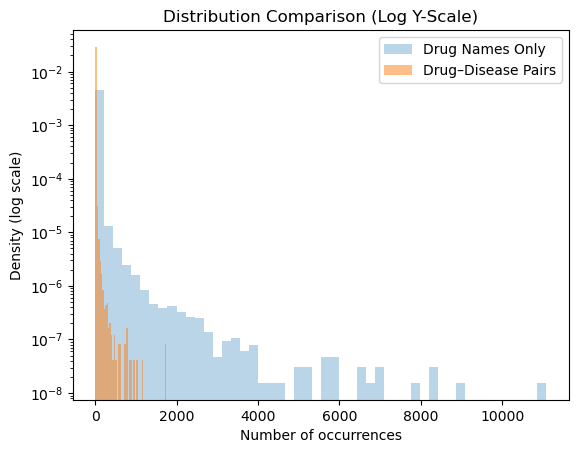

In [128]:
# ---- Recompute pair counts ----
preclin_counts_pairs = (
    preclinical_df["disease<>drug"]
    .dropna()
    .astype(str)
    .value_counts()
)

# ---- Load drug-only counts ----
with open("out/drug_only_counts.json", "r") as f:
    loaded_dict = json.load(f)

drug_counts_loaded = pd.Series(loaded_dict).astype(int)

# Pair distribution
pairs_values = preclin_counts_pairs.values

# Drug-only distribution (loaded from JSON earlier)
drugs_values = drug_counts_loaded.values

plt.figure()

plt.hist(drugs_values, bins=50, density=True, alpha=0.3, label="Drug Names Only")
plt.hist(pairs_values, bins=50, density=True, alpha=0.5, label="Drug–Disease Pairs")


plt.yscale("log")

plt.xlabel("Number of occurrences")
plt.ylabel("Density (log scale)")
plt.title("Distribution Comparison (Log Y-Scale)")

plt.legend()
plt.show()

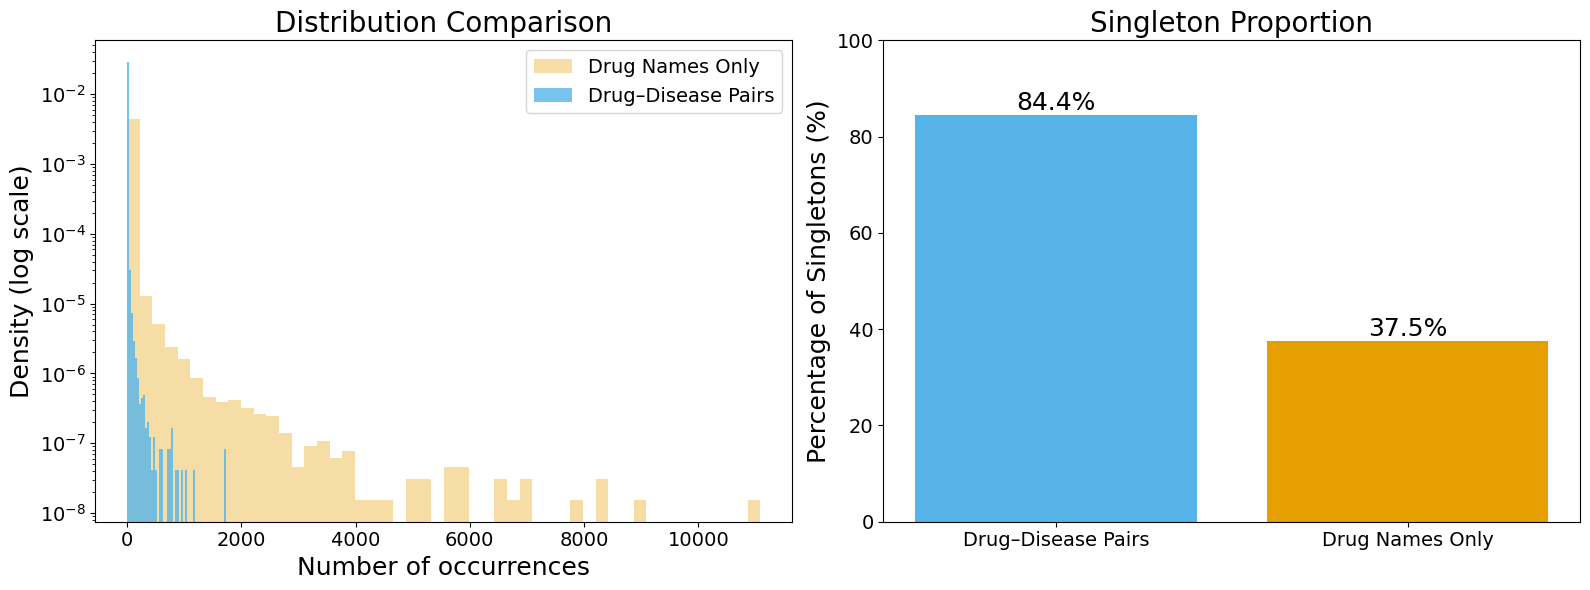

In [129]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_pair_vs_drug_distributions_side_by_side(
    *,
    preclinical_df: pd.DataFrame,
    drugs_col_to_use: str,
    drug_only_counts_json_path: str = "out/drug_only_counts.json",
    pairs_col: str = "disease<>drug",
    bins: int = 50,
    use_density: bool = True,
) -> None:
    """
    End-to-end:
      1) compute pair-count distribution from preclinical_df[pairs_col]
      2) load drug-only counts from JSON (key->count)
      3) plot:
         - left: overlaid hist density (log y)
         - right: % singletons bar chart
      in ONE figure with two panels next to each other
    """

    # -----------------------------
    # 1) Pair counts from preclinical_df
    # -----------------------------
    preclin_counts_pairs = (
        preclinical_df[pairs_col]
        .dropna()
        .astype(str)
        .value_counts()
    )
    pairs_values = preclin_counts_pairs.values

    # -----------------------------
    # 2) Load drug-only counts from JSON
    # -----------------------------
    with open(drug_only_counts_json_path, "r") as f:
        loaded_dict = json.load(f)

    # ensure numeric counts
    drug_counts_loaded = pd.Series(loaded_dict).astype(int)
    drugs_values = drug_counts_loaded.values

    # -----------------------------
    # 3) Singleton stats
    # -----------------------------
    pairs_singletons = int(np.sum(pairs_values == 1))
    pairs_total = int(len(pairs_values))
    pairs_pct = (pairs_singletons / pairs_total * 100) if pairs_total else 0.0

    drugs_singletons = int(np.sum(drugs_values == 1))
    drugs_total = int(len(drugs_values))
    drugs_pct = (drugs_singletons / drugs_total * 100) if drugs_total else 0.0

    # -----------------------------
    # 4) Plot (two panels)
    # -----------------------------
    # Make everything larger and consistent
    LABEL_SIZE = 18
    TITLE_SIZE = 20
    TICK_SIZE = 14
    LEGEND_SIZE = 14
    
    COLOR_DRUG = "#E69F00"
    COLOR_PAIR = "#56B4E9"
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # -------------------------
    # Left panel: histogram
    # -------------------------
    ax1.hist(
        drugs_values,
        bins=bins,
        density=use_density,
        alpha=0.35,
        label="Drug Names Only",
        color=COLOR_DRUG,
    )
    
    ax1.hist(
        pairs_values,
        bins=bins,
        density=use_density,
        alpha=0.80,
        label="Drug–Disease Pairs",
        color=COLOR_PAIR,
    )
    
    ax1.set_yscale("log")
    
    ax1.set_xlabel("Number of occurrences", fontsize=LABEL_SIZE)
    ax1.set_ylabel(
        "Density (log scale)" if use_density else "Count (log scale)",
        fontsize=LABEL_SIZE,
    )
    ax1.set_title("Distribution Comparison", fontsize=TITLE_SIZE)
    
    ax1.tick_params(axis="both", labelsize=TICK_SIZE)
    ax1.legend(fontsize=LEGEND_SIZE)
    
    # -------------------------
    # Right panel: singleton %
    # -------------------------
    labels = ["Drug–Disease Pairs", "Drug Names Only"]
    pcts = [pairs_pct, drugs_pct]
    
    ax2.bar(
        labels,
        pcts,
        color=[COLOR_PAIR, COLOR_DRUG],
    )
    
    ax2.set_ylim(0, 100)
    
    ax2.set_ylabel("Percentage of Singletons (%)", fontsize=LABEL_SIZE)
    ax2.set_title("Singleton Proportion", fontsize=TITLE_SIZE)
    
    ax2.tick_params(axis="both", labelsize=TICK_SIZE)
    
    # Annotate bars
    for i, v in enumerate(pcts):
        ax2.text(i, v, f"{v:.1f}%", ha="center", va="bottom", fontsize=LABEL_SIZE)
    
    plt.tight_layout()
    plt.show()


# -----------------------------
# Example usage
# -----------------------------
plot_pair_vs_drug_distributions_side_by_side(
     preclinical_df=preclinical_df,
     drugs_col_to_use=drugs_col_to_use,
     drug_only_counts_json_path="out/drug_only_counts.json",
 )

## check overlaps with drugs only stats

In [130]:
drugs_from_pairs = {
    item.split("<>")[1].strip()
    for item in reached_clinical_entities
}


In [131]:
len(drugs_from_pairs)

3871

In [ ]:
import json

with open("out/reached_clinical_drug_entities_from_drug_disease_map.json", "w") as f:
    json.dump(list(drugs_from_pairs), f)

In [ ]:
with open("out/reached_clinical_drug_entities.json", "r") as f:
    drugs_only = set(json.load(f))


In [ ]:
len(drugs_only)

In [ ]:
drugs_not_translated_with_disease = drugs_only - drugs_from_pairs

In [ ]:
len(drugs_not_translated_with_disease)

In [ ]:
list(drugs_not_translated_with_disease)[:10]

In [ ]:
filtered_df[
    filtered_df['merged_umls_label']
    .str.contains("prexigebersen", case=False, na=False)
][['normalized_key','clinical_count','preclinical_count']]

In [ ]:
preclinical_df[
    preclinical_df['merged_umls_label']
    .str.contains("prexigebersen", case=False, na=False)
]

In [ ]:
clinical_df[
    clinical_df['merged_umls_label']
    .str.contains("prexigebersen", case=False, na=False)
]

In [ ]:
fda_drug_disease[
    fda_drug_disease['fda_merged_umls_label']
    .str.contains("benfluorex", case=False, na=False)
]

### check specific diseases

In [ ]:
97/1026

In [132]:
report, linked_singletons_df, clinical_unique, p3c_or_p4_unique = clinical_reach_report(
    preclinical_df=preclinical_df,
    filtered_df=filtered_df,
    drugs_col_to_use="merged_umls_termid",
    disease_col_to_use="merged_mondo_termid",
    fda_preclin_not_clin=fda_preclin_not_clin,
    selected_disease="stroke")

Filtering datasets for disease: stroke
Example diseases: ['stroke disorder' 'obsolete susceptibility to ischemic stroke'
 'focal stroke' 'thromboembolic stroke' 'stroke neuroinflammation'
 'photothrombotic stroke' 'neonatal stroke' 'chronic stroke'
 'pediatric arterial ischemic stroke' 'stroke-associated pneumonia']
Example drugs: ['hydroxymethylglutaryl coa reductase inhibitors' '3-methyladenine'
 'simvastatin' 'hsch2ch(ch2ch(ch3)2)co-phenylalanyl-alaninamide' 'xq-1 h'
 'clopidogrel'
 '10-o-(n,n-dimethylaminoethyl)ginkgolide b methanesulfonate' 'xq-1h'
 'jsh 23' 'qnz']
Example FDA: ['stroke disorder <> icosapent ethyl', 'stroke disorder <> dantrolene']
Example excluded infrequent pairs: ['stroke disorder <> acth (4-7)', 'obsolete susceptibility to ischemic stroke <> parp-1 inhibition', 'obsolete susceptibility to ischemic stroke <> way 100635', 'obsolete susceptibility to ischemic stroke <> 3 -', 'obsolete susceptibility to ischemic stroke <> receptor antagonist', 'stroke disorder <> 

In [ ]:
report, linked_singletons_df, clinical_unique, p3c_or_p4_unique = clinical_reach_report(
    preclinical_df=preclinical_df,
    filtered_df=filtered_df,
    drugs_col_to_use="merged_umls_termid",
    disease_col_to_use="merged_mondo_termid",
    fda_preclin_not_clin=fda_preclin_not_clin,
    selected_disease="alzheimer")

In [133]:
report, linked_singletons_df, clinical_unique, p3c_or_p4_unique = clinical_reach_report(
    preclinical_df=preclinical_df,
    filtered_df=filtered_df,
    drugs_col_to_use="merged_umls_termid",
    disease_col_to_use="merged_mondo_termid",
    fda_preclin_not_clin=fda_preclin_not_clin,
    selected_disease="multiple sclerosis")

Filtering datasets for disease: multiple sclerosis
Example diseases: ['multiple sclerosis' 'relapsing-remitting multiple sclerosis'
 'primary progressive multiple sclerosis'
 'chronic progressive multiple sclerosis'
 'progressive relapsing multiple sclerosis'
 'secondary progressive multiple sclerosis'
 'multiple sclerosis, susceptibility to'
 'multiple sclerosis-associated central neuropathic pain'
 'multiple sclerosis-related spasticity' 'multiple sclerosis pathogenesis']
Example drugs: ['fumarate, dimethyl' 'fingolimod' '2cf34ap' 'dalfampridine'
 '3-trifluoromethylpyridine' '2-trifluoromethyl-4-ap' '3me4ap'
 '4-aminopyridine k [+] channel blockers' '3-methyl-4-aminopyridine'
 '3f4ap']
Example FDA: []
Example excluded infrequent pairs: ['multiple sclerosis <> inhibitor of the mitochondrial calcium uniporter', 'multiple sclerosis <> immunoproteasome inhibitors', 'multiple sclerosis <> anti-cxcl12', 'multiple sclerosis <> [111] in-ocrelizumab', 'multiple sclerosis <> ccl1-ig', 'multipl

In [64]:
report, linked_singletons_df, clinical_unique, p3c_or_p4_unique = clinical_reach_report(
    preclinical_df=preclinical_df,
    filtered_df=filtered_df,
    drugs_col_to_use="merged_umls_termid",
    disease_col_to_use="merged_mondo_termid",
    fda_preclin_not_clin=fda_preclin_not_clin,
    selected_disease="epilepsy")

Filtering datasets for disease: epilepsy
Example diseases: ['glioma-associated epilepsy' 'epilepsy' 'complex partial epilepsy'
 'epilepsy with generalized tonic-clonic seizures'
 'idiopathic generalized epilepsy' 'epilepsy syndrome'
 'obsolete absence epilepsy' 'temporal lobe epilepsy'
 'post-traumatic epilepsy' 'childhood absence epilepsy']
Example drugs: ['perampanel' 'ginsenoside m1' 'drugs' 'antiepileptic' 'levetiracetam'
 'ocimum sanctum whole extract' 'catalpol' 'mannitol' 'pyrilamine' 'e177']
Example FDA: ['idiopathic generalized epilepsy <> felbamate', 'focal epilepsy <> primidone', 'temporal lobe epilepsy <> phenytoin', 'focal epilepsy <> harkoseride', 'obsolete absence epilepsy <> divalproex sodium', 'focal epilepsy <> neurontin', 'complex partial epilepsy <> valproic acid', 'complex partial epilepsy <> valproate', 'focal epilepsy <> everolimus', 'epilepsy <> felbamate']
Example excluded infrequent pairs: ['epilepsy <> faa2', 'epilepsy <> nicotinamide mononucleotide', 'idiopa

In [65]:
report, linked_singletons_df, clinical_unique, p3c_or_p4_unique = clinical_reach_report(
    preclinical_df=preclinical_df,
    filtered_df=filtered_df,
    drugs_col_to_use="merged_umls_termid",
    disease_col_to_use="merged_mondo_termid",
    fda_preclin_not_clin=fda_preclin_not_clin,
    selected_disease="schizophrenia")

Filtering datasets for disease: schizophrenia
Example diseases: ['schizophrenia' 'cognitive impairment associated with schizophrenia'
 'negative symptoms of schizophrenia' 'obsolete schizophrenia'
 'paranoid schizophrenia' 'schizophrenia and bipolar disorder'
 'treatment-refractory schizophrenia' 'deletion-associated schizophrenia'
 "autism alzheimer's schizophrenia"
 'cognitive impairment in schizophrenia']
Example drugs: ['nicotine' 'ferulic acid' 'cholinesterase inhibitor' 'ferulate' 'fk-506'
 'tacrolimus' 'clozapine' 'haloperidol'
 'pyrrolidine allosteric modulators' 'aniracetam']
Example FDA: ['schizophrenia <> hydrochloride, chlorpromazine', 'paranoid schizophrenia <> fluphenazine', 'schizophrenia <> thioridazine']
Example excluded infrequent pairs: ['schizophrenia <> βarr2-biased d2r ligand', 'schizophrenia <> second generation atypical apd', 'schizophrenia <> agonist pam', 'schizophrenia <> eeds', 'schizophrenia <> no [•] releasers', 'schizophrenia <> muscarinic m1 receptor ago

In [66]:
report, linked_singletons_df, clinical_unique, p3c_or_p4_unique = clinical_reach_report(
    preclinical_df=preclinical_df,
    filtered_df=filtered_df,
    drugs_col_to_use="merged_umls_termid",
    disease_col_to_use="merged_mondo_termid",
    fda_preclin_not_clin=fda_preclin_not_clin,
    selected_disease="sleep")

Filtering datasets for disease: sleep
Example diseases: ['sleep apnea syndrome' 'complex sleep apnea'
 'obstructive sleep apnea syndrome' 'excessive daytime sleepiness'
 'sleep deprivation' 'high-altitude sleep disturbance'
 'sleep-wake disorder' 'sleep' 'sleep disorder'
 'sleep deprivation-induced pain hypersensitivity']
Example drugs: ['α1-adrenergic-antagonist' 'alpha-1 adrenergic-antagonist'
 'α1-adrenergic antagonists' 'α1-adrenergic antagonist'
 'protocatechuic acid' 'nonselective d2 antagonist' 'sch 39166'
 'modafinil' 'selective d1 antagonist' '91356a']
Example FDA: ['sleep disorder <> hydrochloride, doxepin']
Example excluded infrequent pairs: ['sleep apnea syndrome <> tetrakis(n-methyl-4-pyridiniumyl)porphine manganese(iii) complex', 'obstructive sleep apnea syndrome <> 5ht2', 'rem sleep behavior disorder <> beta adrenoceptor', 'sleep <> terazosin', 'obstructive sleep apnea syndrome <> u 0126', 'sleep-wake disorder <> dual orexin 1 and orexin 2 receptor antagonist', 'paradoxi

In [ ]:
clinical_unique

In [107]:
example = "multiple sclerosis <> ponesimod"
example in p3c_or_p4_unique

True

In [101]:
filtered_df[filtered_df['normalized_key']==example]

,normalized_key,clinical_doc_ids,merged_mondo_termid,merged_umls_termid,phase,overall_status,clinical_count,preclinical_doc_ids,merged_mondo_termid_right,merged_umls_termid_right,preclinical_count,max_phase,at_least_one_phase3,at_least_one_phase3_completed,at_least_one_phase4
48240,multiple sclerosis <> ponesimod,"[NCT01093326, NCT02425644, NCT02907177, NCT032...",MONDO:0005301,C2934701,"[Phase 2, Phase 3, Phase 3, Phase 3]","[Completed, Completed, Terminated, Completed]",4.0,"[31214480, 34986275, 36419359, 38243760]",MONDO:0005301,C2934701,4.0,Phase 3,True,True,False


In [ ]:
n_in_clinical_linked = sum(_is_linked(e, mapping_lookup) for e in list(filtered_df.normalized_key))
n_in_clinical_linked

In [92]:
13570/1808059, 9028/266688

(0.007505286055377617, 0.03385229181665467)

In [61]:
912+97

1009

In [62]:
97/1009

0.09613478691774034

In [82]:
 12456/68759

0.18115446705158597